# Titanic Survival Prediction

### Data Dictionary

| Variable | Definition | Key |
|---|---|---|
| `survived` | Survival | 0 = No, 1 = Yes |
| `pclass` | Ticket class | 1 = 1st, 2 = 2nd, 3 = 3rd |
| `sex` | Sex | |
| `age` | Age in years | |
| `sibsp` | Number of siblings / spouses aboard the Titanic | |
| `parch` | Number of parents / children aboard the Titanic | |
| `ticket` | Ticket number | |
| `fare` | Passenger fare | |
| `cabin` | Cabin number | |
| `embarked` | Port of Embarkation | C = Cherbourg, Q = Queenstown, S = Southampton |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
train_pd = pd.read_csv('../data/train.csv')
test_pd = pd.read_csv('../data/test.csv')

print('Training Data:')
display(train_pd)

print('\nTesting Data')
display(test_pd)

Training Data:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C



Testing Data


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


We notice that the only difference between the two datasets is the `Survived` column. Therefore, we drop the `Survived` column from the training dataset, save it separately, and combine both datasets into a single DataFrame.

In [3]:
survived = train_pd['Survived']
#we drop the column now
train_pd = train_pd.drop(['Survived'], axis=1)

train_idx = train_pd['PassengerId']
test_idx = test_pd['PassengerId']

combined_pd = pd.concat([train_pd, test_pd]).reset_index(drop=True)

display(combined_pd)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


# missing values 

In [4]:
print(combined_pd.isnull().sum())

PassengerId       0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64


Now let's deal with the age

In [5]:
combined_pd.groupby('Pclass')['Age'].median()

Pclass
1    39.0
2    29.0
3    24.0
Name: Age, dtype: float64

based on the Ticket class the median age is different 

In [6]:
combined_pd['Age'] = combined_pd['Age'].fillna(
    combined_pd.groupby('Pclass')['Age'].transform('median')
)

display(combined_pd)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,NaN,S


In [7]:
# now fo the fare 
display(combined_pd[combined_pd['Fare'].isnull()])

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1043,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [8]:
combined_pd.groupby('Embarked')['Fare'].median()

Embarked
C    28.51875
Q     7.75000
S    13.00000
Name: Fare, dtype: float64

In [9]:
combined_pd.groupby('Pclass')['Fare'].median()

Pclass
1    60.0000
2    15.0458
3     8.0500
Name: Fare, dtype: float64

In [10]:
combined_pd.groupby(['Pclass', 'Embarked'])['Fare'].median()

Pclass  Embarked
1       C           76.7292
        Q           90.0000
        S           52.0000
2       C           15.3146
        Q           12.3500
        S           15.3750
3       C            7.8958
        Q            7.7500
        S            8.0500
Name: Fare, dtype: float64

In [11]:
median_fare = combined_pd.groupby(['Pclass', 'Embarked'])['Fare'].transform('median')

combined_pd['Fare'] = combined_pd['Fare'].fillna(median_fare)

display(combined_pd[combined_pd['PassengerId'] == 1044])

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1043,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,8.05,NaN,S


In [12]:
display(combined_pd[combined_pd['Embarked'].isnull()])

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [13]:
combined_pd[combined_pd['Pclass'] == 1]['Embarked'].value_counts()

Embarked
S    177
C    141
Q      3
Name: count, dtype: int64

In [14]:
combined_pd[
    (combined_pd['Pclass'] == 1) &
    (combined_pd['Fare'].between(70, 90))
]['Embarked'].value_counts()

Embarked
C    29
S    25
Q     3
Name: count, dtype: int64

In [15]:
# we fill with the most C
combined_pd['Embarked'] = combined_pd['Embarked'].fillna('C')
display(combined_pd[combined_pd['Embarked'].isnull()])

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [16]:
combined_pd['Cabin'] = combined_pd['Cabin'].fillna('M')
combined_pd['Cabin'] = combined_pd['Cabin'].str[0]
combined_pd['Cabin'].value_counts()

Cabin
M    1014
C      94
B      65
D      46
E      41
A      22
F      21
G       5
T       1
Name: count, dtype: int64

In [17]:
combined_pd['Cabin'] = combined_pd['Cabin'].replace('T', 'M')
combined_pd['Cabin'].value_counts()

Cabin
M    1015
C      94
B      65
D      46
E      41
A      22
F      21
G       5
Name: count, dtype: int64

In [18]:
print(combined_pd.isnull().sum())

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


## Now as we finsihed the missing values next is to build the model 

In [19]:
display(combined_pd)
combined_pd.nunique()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S
...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,M,S
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,C
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,M,S
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,M,S


PassengerId    1309
Pclass            3
Name           1307
Sex               2
Age              98
SibSp             7
Parch             8
Ticket          929
Fare            281
Cabin             8
Embarked          3
dtype: int64

 We extract the titles from the `Name` column and group similar titles into broader categories.

In [20]:
last_names = combined_pd['Name'].str.split(',').str[0]

titles = combined_pd['Name'].str.extract(r',\s*([^.]*)\.')[0]

first_names = combined_pd['Name'].str.extract(r'\.\s*(.*)')[0]

title_mapping = {
    'Capt': 'Military',
    'Col': 'Military',
    'Major': 'Military',
    'Dr': 'Professional',
    'Rev': 'Professional',
    'Don': 'Nobility',
    'Dona': 'Nobility',
    'Lady': 'Nobility',
    'Sir': 'Nobility',
    'Jonkheer': 'Nobility',
    'Countess': 'Nobility',
    'the Countess': 'Nobility',
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs'
}

titles = titles.replace(title_mapping)

last_names = last_names.to_numpy()
titles = titles.to_numpy()
first_names = first_names.to_numpy()

print('\n')
print(np.unique(titles, return_counts=True))



(array(['Master', 'Military', 'Miss', 'Mr', 'Mrs', 'Nobility',
       'Professional'], dtype=object), array([ 61,   7, 264, 757, 198,   6,  16]))


In [21]:
combined_pd['Title'] = titles
combined_pd[['Name', 'Title']].head()

,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr


To make the `Age` feature more useful, we group passengers into different age categories. This reduces the number of unique values and allows the model to identify patterns between different age groups.

In [22]:
bins = [0, 5, 12, 18, 30, 50, 65, np.inf]
labels = ['Baby', 'Child', 'Teen', 'Young Adult', 'Adult', 'Senior', 'Elderly']

combined_pd['AgeGroup'] = pd.cut(
    combined_pd['Age'],
    bins=bins,
    labels=labels
)
 
combined_pd['AgeGroup'].value_counts()

AgeGroup
Young Adult    640
Adult          381
Teen            99
Senior          85
Baby            56
Child           38
Elderly         10
Name: count, dtype: int64

In [23]:
combined_pd['TicketGroupSize'] = combined_pd.groupby('Ticket')['Ticket'].transform('count')
print(combined_pd['TicketGroupSize'].value_counts())

combined_pd['FarePerTicket'] = combined_pd['Fare'] / combined_pd['TicketGroupSize']

TicketGroupSize
1     713
2     264
3     147
4      64
5      35
7      35
6      24
8      16
11     11
Name: count, dtype: int64


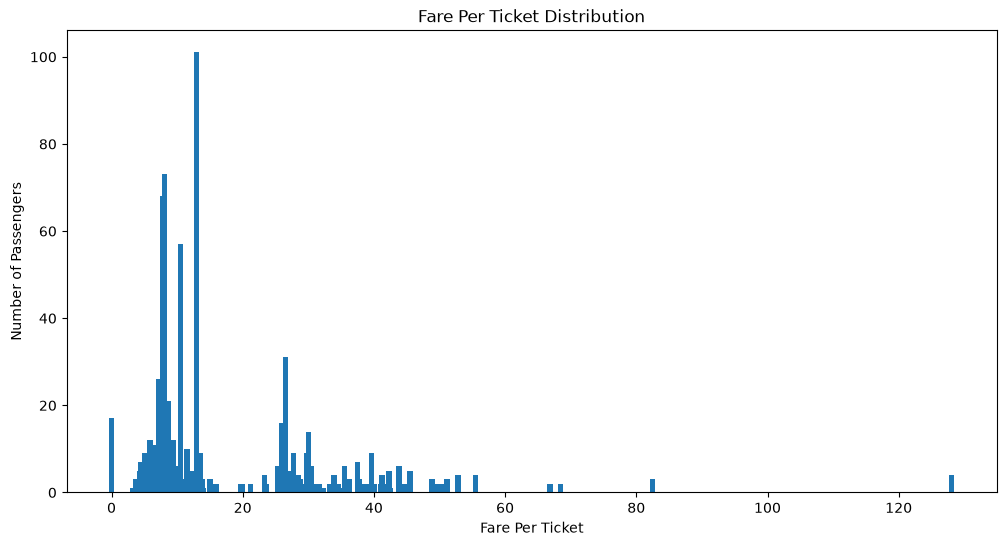

In [24]:
fare_counts = combined_pd['FarePerTicket'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.bar(fare_counts.index, fare_counts.values)

plt.title('Fare Per Ticket Distribution')
plt.xlabel('Fare Per Ticket')
plt.ylabel('Number of Passengers')
plt.show()

In [25]:
bins = [0, 20, 40, 60, 80, 100, np.inf]
labels = ['0-20', '20-40', '40-60', '60-80', '80-100', '100+']

combined_pd['FareGroup'] = pd.cut(
    combined_pd['FarePerTicket'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

combined_pd['FareGroup'].value_counts().sort_index()
display(combined_pd)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,AgeGroup,TicketGroupSize,FarePerTicket,FareGroup
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,Mr,Young Adult,1,7.250000,0-20
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs,Adult,2,35.641650,20-40
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,Miss,Young Adult,1,7.925000,0-20
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs,Adult,2,26.550000,20-40
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,Mr,Adult,1,8.050000,0-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,M,S,Mr,Young Adult,1,8.050000,0-20
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,C,Nobility,Adult,3,36.300000,20-40
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,M,S,Mr,Adult,1,7.250000,0-20
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,M,S,Mr,Young Adult,1,8.050000,0-20


In [26]:
combined_pd['FamilySize'] = combined_pd['SibSp'] + combined_pd['Parch']

display(combined_pd)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,AgeGroup,TicketGroupSize,FarePerTicket,FareGroup,FamilySize
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,Mr,Young Adult,1,7.250000,0-20,1
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,Mrs,Adult,2,35.641650,20-40,1
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,Miss,Young Adult,1,7.925000,0-20,0
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,Mrs,Adult,2,26.550000,20-40,1
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,Mr,Adult,1,8.050000,0-20,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,"Spector, Mr. Woolf",male,24.0,0,0,A.5. 3236,8.0500,M,S,Mr,Young Adult,1,8.050000,0-20,0
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C,C,Nobility,Adult,3,36.300000,20-40,0
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,M,S,Mr,Adult,1,7.250000,0-20,0
1307,1308,3,"Ware, Mr. Frederick",male,24.0,0,0,359309,8.0500,M,S,Mr,Young Adult,1,8.050000,0-20,0


## We drop the original columns that have already been processed into new features.

In [27]:
combined_pd = combined_pd.drop(
    columns=[
        'Name',
        'Ticket',
        'Age',
        'Fare',
        'FarePerTicket',
        'TicketGroupSize'
    ]
)

display(combined_pd)

,PassengerId,Pclass,Sex,SibSp,Parch,Cabin,Embarked,Title,AgeGroup,FareGroup,FamilySize
0,1,3,male,1,0,M,S,Mr,Young Adult,0-20,1
1,2,1,female,1,0,C,C,Mrs,Adult,20-40,1
2,3,3,female,0,0,M,S,Miss,Young Adult,0-20,0
3,4,1,female,1,0,C,S,Mrs,Adult,20-40,1
4,5,3,male,0,0,M,S,Mr,Adult,0-20,0
...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,male,0,0,M,S,Mr,Young Adult,0-20,0
1305,1306,1,female,0,0,C,C,Nobility,Adult,20-40,0
1306,1307,3,male,0,0,M,S,Mr,Adult,0-20,0
1307,1308,3,male,0,0,M,S,Mr,Young Adult,0-20,0


In [28]:
print(combined_pd.nunique())

PassengerId    1309
Pclass            3
Sex               2
SibSp             7
Parch             8
Cabin             8
Embarked          3
Title             7
AgeGroup          7
FareGroup         6
FamilySize        9
dtype: int64
